# 07 - Node2Vec vs GraphSAGE

Head-to-head of the two embedding families per dataset, looking at both the **embedding size** (32 / 64 / 128 dims) and the family choice.

The `05_embedding_selection` notebooks do not save metric files, so the numbers below are taken directly from those notebooks' saved cell outputs: the best ML model for each embedding (post-tuning leaderboard top). Dataset 2's `train_mae` was not kept in the saved output, so it was reproduced by re-running the selection (fixed seeds; all other metrics match exactly). All metrics are on `log_systemic_risk_label`.

- Dataset 1: temporal split
- Dataset 2: random split
- Dataset 3: random split, **Node2Vec only** (GraphSAGE not applicable to a structure-only network)

`chosen` marks the embedding+model carried into the `05_embedding_threshold` sweep.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Best ML model per embedding, curated from 05_embedding_selection_*.ipynb saved outputs.
# dataset, family, version, dim, ml_model, train_mae, val_mae, train_rmse, val_rmse, chosen
rows = [
    ('Dataset 1', 'GraphSAGE', 'v1',  32, 'MLP (tuned)',               0.020, 0.026, 0.096, 0.122, True),
    ('Dataset 1', 'GraphSAGE', 'v1',  64, 'MLP (tuned)',               0.027, 0.029, 0.127, 0.134, False),
    ('Dataset 1', 'GraphSAGE', 'v1', 128, 'MLP (tuned)',               0.030, 0.035, 0.138, 0.166, False),
    ('Dataset 1', 'GraphSAGE', 'v2',  32, 'MLP (tuned)',               0.020, 0.050, 0.058, 0.142, False),
    ('Dataset 1', 'GraphSAGE', 'v2',  64, 'MLP (tuned)',               0.025, 0.041, 0.081, 0.168, False),
    ('Dataset 1', 'GraphSAGE', 'v2', 128, 'MLP (tuned)',               0.028, 0.051, 0.118, 0.176, False),
    ('Dataset 1', 'Node2Vec',  'v1',  32, 'Random Forest (tuned)',     0.009, 0.029, 0.045, 0.129, False),
    ('Dataset 1', 'Node2Vec',  'v1',  64, 'Random Forest (tuned)',     0.008, 0.028, 0.040, 0.127, False),
    ('Dataset 1', 'Node2Vec',  'v1', 128, 'Random Forest (tuned)',     0.010, 0.028, 0.051, 0.121, False),
    ('Dataset 1', 'Node2Vec',  'v2',  32, 'Random Forest (tuned)',     0.012, 0.031, 0.057, 0.127, False),
    ('Dataset 1', 'Node2Vec',  'v2',  64, 'Random Forest (tuned)',     0.008, 0.028, 0.040, 0.125, False),
    ('Dataset 1', 'Node2Vec',  'v2', 128, 'Random Forest',             0.006, 0.034, 0.032, 0.129, False),

    ('Dataset 2', 'GraphSAGE', 'v1',  32, 'XGBoost (tuned)',           0.030, 0.057, 0.073, 0.131, False),
    ('Dataset 2', 'GraphSAGE', 'v1',  64, 'MLP (tuned)',               0.054, 0.063, 0.137, 0.142, True),
    ('Dataset 2', 'GraphSAGE', 'v1', 128, 'MLP (tuned)',               0.060, 0.071, 0.123, 0.147, False),
    ('Dataset 2', 'GraphSAGE', 'v2',  32, 'MLP (tuned)',               0.043, 0.061, 0.121, 0.148, False),
    ('Dataset 2', 'GraphSAGE', 'v2',  64, 'Linear Regression',         0.063, 0.074, 0.133, 0.147, False),
    ('Dataset 2', 'GraphSAGE', 'v2', 128, 'MLP (tuned)',               0.054, 0.063, 0.135, 0.145, False),
    ('Dataset 2', 'Node2Vec',  'v1',  32, 'Gradient Boosting (tuned)', 0.008, 0.064, 0.026, 0.163, False),
    ('Dataset 2', 'Node2Vec',  'v1',  64, 'XGBoost (tuned)',           0.043, 0.065, 0.100, 0.166, False),
    ('Dataset 2', 'Node2Vec',  'v1', 128, 'Random Forest (tuned)',     0.047, 0.065, 0.123, 0.161, False),
    ('Dataset 2', 'Node2Vec',  'v2',  32, 'MLP (tuned)',               0.062, 0.077, 0.119, 0.157, False),
    ('Dataset 2', 'Node2Vec',  'v2',  64, 'XGBoost',                   0.004, 0.058, 0.009, 0.159, False),
    ('Dataset 2', 'Node2Vec',  'v2', 128, 'XGBoost (tuned)',           0.053, 0.060, 0.129, 0.161, False),

    ('Dataset 3', 'Node2Vec',  'v1',  32, 'MLP (tuned)',               0.407, 0.477, 0.616, 0.706, False),
    ('Dataset 3', 'Node2Vec',  'v1',  64, 'MLP (tuned)',               0.399, 0.482, 0.603, 0.724, False),
    ('Dataset 3', 'Node2Vec',  'v1', 128, 'Gradient Boosting (tuned)', 0.162, 0.526, 0.219, 0.722, False),
    ('Dataset 3', 'Node2Vec',  'v2',  32, 'MLP (tuned)',               0.380, 0.451, 0.577, 0.682, True),
    ('Dataset 3', 'Node2Vec',  'v2',  64, 'Gradient Boosting (tuned)', 0.188, 0.501, 0.261, 0.703, False),
    ('Dataset 3', 'Node2Vec',  'v2', 128, 'Gradient Boosting (tuned)', 0.159, 0.509, 0.219, 0.696, False),
]

df = pd.DataFrame(rows, columns=[
    'dataset', 'family', 'version', 'dim', 'ml_model',
    'train_mae', 'val_mae', 'train_rmse', 'val_rmse', 'chosen',
])
df['approach'] = df['family'] + '-' + df['version']
df

,dataset,family,version,dim,ml_model,train_mae,val_mae,train_rmse,val_rmse,chosen,approach
0,Dataset 1,GraphSAGE,v1,32,MLP (tuned),0.020,0.026,0.096,0.122,True,GraphSAGE-v1
1,Dataset 1,GraphSAGE,v1,64,MLP (tuned),0.027,0.029,0.127,0.134,False,GraphSAGE-v1
2,Dataset 1,GraphSAGE,v1,128,MLP (tuned),0.030,0.035,0.138,0.166,False,GraphSAGE-v1
3,Dataset 1,GraphSAGE,v2,32,MLP (tuned),0.020,0.050,0.058,0.142,False,GraphSAGE-v2
4,Dataset 1,GraphSAGE,v2,64,MLP (tuned),0.025,0.041,0.081,0.168,False,GraphSAGE-v2
5,Dataset 1,GraphSAGE,v2,128,MLP (tuned),0.028,0.051,0.118,0.176,False,GraphSAGE-v2
6,Dataset 1,Node2Vec,v1,32,Random Forest (tuned),0.009,0.029,0.045,0.129,False,Node2Vec-v1
7,Dataset 1,Node2Vec,v1,64,Random Forest (tuned),0.008,0.028,0.040,0.127,False,Node2Vec-v1
8,Dataset 1,Node2Vec,v1,128,Random Forest (tuned),0.010,0.028,0.051,0.121,False,Node2Vec-v1
9,Dataset 1,Node2Vec,v2,32,Random Forest (tuned),0.012,0.031,0.057,0.127,False,Node2Vec-v2


In [2]:
# Selection rule used throughout this notebook. Pick the lowest validation-RMSE
# candidate per group, but ALWAYS discount models that overfit severely — a validation
# RMSE more than 3x the training RMSE means the model has essentially memorised the
# train set and can top a leaderboard while generalising no better (e.g. Dataset 2
# Node2Vec 64-dim, untuned XGBoost: train RMSE 0.009 vs val 0.159). A severe overfitter
# is only kept when every candidate in its group is one.
def select_best(frame, group_cols, by='val_rmse'):
    f = frame.copy()
    f['_severe'] = (f['val_rmse'] / f['train_rmse']) > 3
    return (f.sort_values(['_severe', by])
              .groupby(group_cols, as_index=False, sort=False)
              .first()
              .drop(columns='_severe'))

## 1. Dataset 1 — embedding size vs results (overall + top 1%)

Train (faded dashed) and validation (solid) error vs embedding dimension, for both MAE and RMSE. Top row = all observations, bottom row = top 1% highest systemic-risk observations (the tail that matters most; saved only for Dataset 1). Each approach has its own colour; the enlarged black-edged marker is the final chosen model.

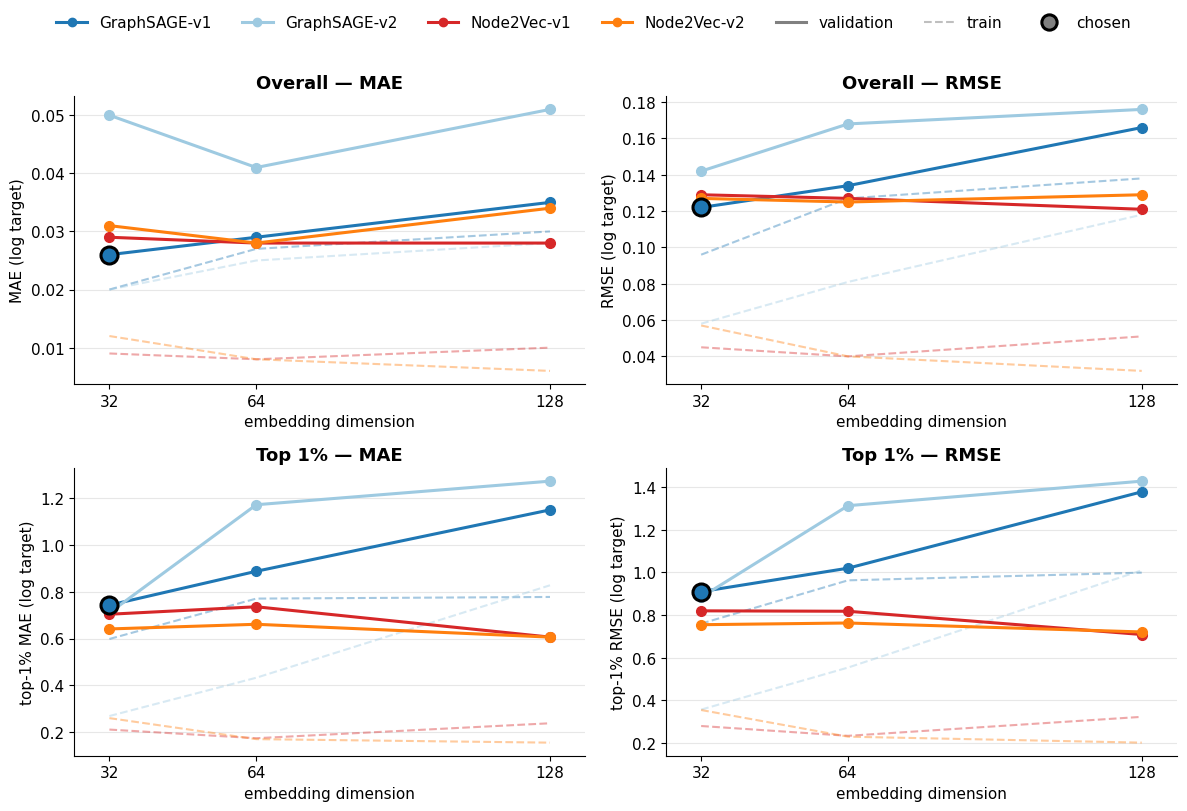

In [3]:
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})

# One distinct colour per approach. Solid = validation, faded dashed = train.
acolors = {
    'GraphSAGE-v1': '#1f77b4',  # blue
    'GraphSAGE-v2': '#9ecae1',  # light blue
    'Node2Vec-v1':  '#d62728',  # red
    'Node2Vec-v2':  '#ff7f0e',  # orange
}
datasets = df['dataset'].unique()

# Top-1% metrics for Dataset 1 (error on the top 1% highest systemic-risk rows),
# from the dataset_1/05_embedding_selection_p0_v1 & _v2 saved outputs.
# Same best-per-embedding model as in the main table.
d1_top1 = pd.DataFrame([
    # approach, dim, train_top1_mae, val_top1_mae, train_top1_rmse, val_top1_rmse
    ('GraphSAGE-v1',  32, 0.598, 0.743, 0.760, 0.910),
    ('GraphSAGE-v1',  64, 0.771, 0.888, 0.963, 1.020),
    ('GraphSAGE-v1', 128, 0.778, 1.151, 0.999, 1.378),
    ('GraphSAGE-v2',  32, 0.268, 0.710, 0.357, 0.884),
    ('GraphSAGE-v2',  64, 0.432, 1.173, 0.554, 1.313),
    ('GraphSAGE-v2', 128, 0.828, 1.274, 1.010, 1.428),
    ('Node2Vec-v1',   32, 0.210, 0.704, 0.280, 0.820),
    ('Node2Vec-v1',   64, 0.173, 0.736, 0.234, 0.818),
    ('Node2Vec-v1',  128, 0.237, 0.606, 0.323, 0.709),
    ('Node2Vec-v2',   32, 0.259, 0.641, 0.355, 0.755),
    ('Node2Vec-v2',   64, 0.169, 0.661, 0.230, 0.763),
    ('Node2Vec-v2',  128, 0.154, 0.606, 0.202, 0.721),
], columns=['approach', 'dim', 'train_top1_mae', 'val_top1_mae', 'train_top1_rmse', 'val_top1_rmse'])

D1_CHOSEN = ('GraphSAGE-v1', 32)


def plot_metric(ax, data, tcol, vcol, title, ylabel, chosen):
    for app, g in data.groupby('approach'):
        g = g.sort_values('dim')
        col = acolors[app]
        ax.plot(g['dim'], g[vcol], '-o', color=col, linewidth=2.2, markersize=7, zorder=3)
        ax.plot(g['dim'], g[tcol], '--', color=col, linewidth=1.5, alpha=0.4, zorder=2)
    ch = data[(data['approach'] == chosen[0]) & (data['dim'] == chosen[1])]
    for _, row in ch.iterrows():
        ax.scatter(row['dim'], row[vcol], s=150, color=acolors[row['approach']],
                   edgecolors='black', linewidths=2.2, zorder=6)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('embedding dimension')
    ax.set_xticks([32, 64, 128])
    ax.margins(x=0.08)
    ax.grid(True, axis='y', alpha=0.3)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)


def metric_legend(fig):
    handles = [Line2D([0], [0], color=acolors[a], marker='o', linewidth=2.2, label=a) for a in acolors]
    handles += [
        Line2D([0], [0], color='gray', linestyle='-', linewidth=2.2, label='validation'),
        Line2D([0], [0], color='gray', linestyle='--', alpha=0.5, label='train'),
        Line2D([0], [0], marker='o', markerfacecolor='gray', markeredgecolor='black',
               markersize=11, markeredgewidth=2.2, linestyle='None', label='chosen'),
    ]
    fig.legend(handles=handles, loc='upper center', ncol=7, frameon=False, bbox_to_anchor=(0.5, 1.02))


# Dataset 1: overall (top row) + top-1% (bottom row)
d1 = df[df['dataset'] == 'Dataset 1']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_metric(axes[0, 0], d1, 'train_mae', 'val_mae', 'Overall — MAE', 'MAE (log target)', D1_CHOSEN)
plot_metric(axes[0, 1], d1, 'train_rmse', 'val_rmse', 'Overall — RMSE', 'RMSE (log target)', D1_CHOSEN)
plot_metric(axes[1, 0], d1_top1, 'train_top1_mae', 'val_top1_mae', 'Top 1% — MAE', 'top-1% MAE (log target)', D1_CHOSEN)
plot_metric(axes[1, 1], d1_top1, 'train_top1_rmse', 'val_top1_rmse', 'Top 1% — RMSE', 'top-1% RMSE (log target)', D1_CHOSEN)
metric_legend(fig)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('n2v_vs_graphsage_dataset1.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Datasets 2 & 3 — embedding size vs results

Same view for the other two datasets (overall MAE and RMSE; top-1% was not saved for these). Dataset 3 is Node2Vec only.

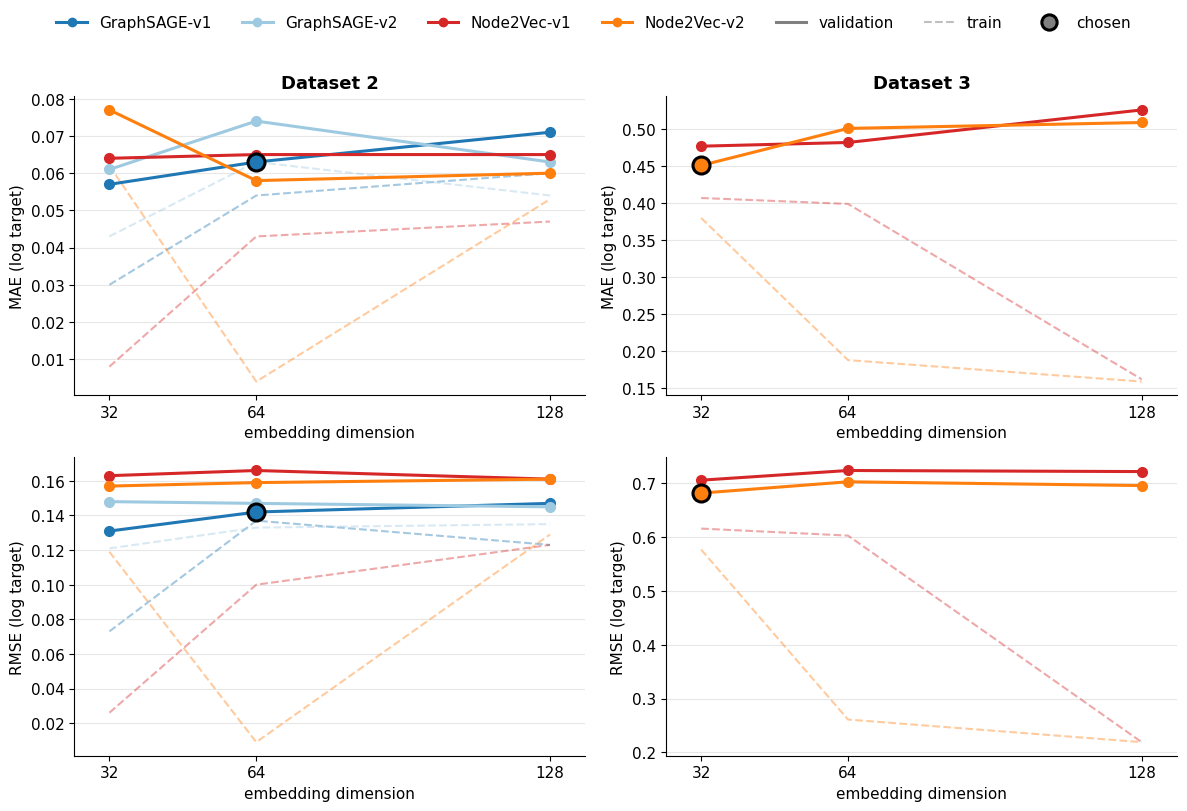

In [4]:
# Datasets 2 & 3: overall MAE (top) and RMSE (bottom). Reuses plot_metric / acolors from above.
ds23 = ['Dataset 2', 'Dataset 3']
chosen_by_ds = {'Dataset 2': ('GraphSAGE-v1', 64), 'Dataset 3': ('Node2Vec-v2', 32)}
metrics = [('MAE', 'train_mae', 'val_mae'), ('RMSE', 'train_rmse', 'val_rmse')]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for r, (mname, tcol, vcol) in enumerate(metrics):
    for c, ds in enumerate(ds23):
        plot_metric(axes[r, c], df[df['dataset'] == ds], tcol, vcol,
                    ds if r == 0 else '', f'{mname} (log target)', chosen_by_ds[ds])
metric_legend(fig)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('n2v_vs_graphsage_dataset2_3.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Same numbers as a wide table: val RMSE per approach x dimension.
for ds in datasets:
    print(f'\n=== {ds} — validation RMSE by dimension ===')
    piv = df[df['dataset'] == ds].pivot_table(index='approach', columns='dim', values='val_rmse')
    print(piv.to_string())


=== Dataset 1 — validation RMSE by dimension ===
dim            32    64    128
approach                      
GraphSAGE-v1 0.122 0.134 0.166
GraphSAGE-v2 0.142 0.168 0.176
Node2Vec-v1  0.129 0.127 0.121
Node2Vec-v2  0.127 0.125 0.129

=== Dataset 2 — validation RMSE by dimension ===
dim            32    64    128
approach                      
GraphSAGE-v1 0.131 0.142 0.147
GraphSAGE-v2 0.148 0.147 0.145
Node2Vec-v1  0.163 0.166 0.161
Node2Vec-v2  0.157 0.159 0.161

=== Dataset 3 — validation RMSE by dimension ===
dim           32    64    128
approach                     
Node2Vec-v1 0.706 0.724 0.722
Node2Vec-v2 0.682 0.703 0.696


## 3. GraphSAGE vs Node2Vec, at each size

Best of each family (across v1/v2) at every embedding dimension. For each family+dimension we take the version with the lowest validation RMSE, skipping a version that overfits severely (val/train RMSE ratio > 3) when a non-severe alternative exists — otherwise an untuned, memorised model (e.g. Dataset 2 Node2Vec 64-dim) would represent the family on a near-zero train bar. The same version is used for both the MAE and RMSE panels. Solid bar = validation, hatched bar = train; the gap between them is the overfitting. Shown for both MAE and RMSE.

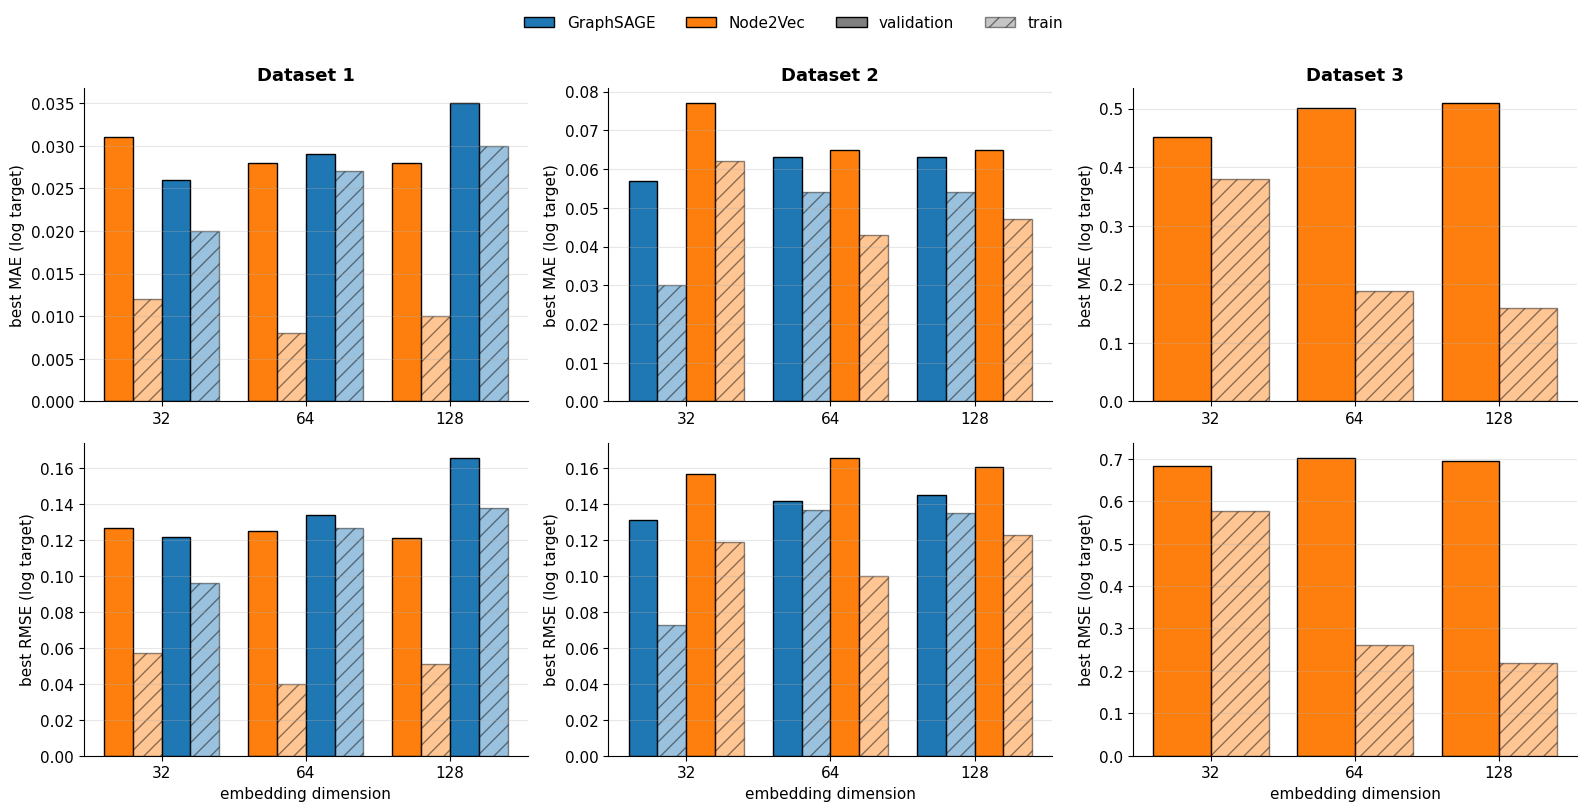

In [6]:
from matplotlib.patches import Patch

# One version (v1/v2) represents each family at each embedding size, chosen with
# select_best — so a severely-overfit model never stands in for a family (this is what
# flips Dataset 2 Node2Vec 64-dim from v2's untuned XGBoost to v1's tuned one). The same
# chosen version is reused for both the MAE and RMSE panels so they stay consistent.
colors = {'GraphSAGE': '#1f77b4', 'Node2Vec': '#ff7f0e'}
metrics = [('MAE', 'train_mae', 'val_mae'), ('RMSE', 'train_rmse', 'val_rmse')]
dims = [32, 64, 128]

best_fam_dim = select_best(df, ['dataset', 'family', 'dim'])

fig, axes = plt.subplots(2, len(datasets), figsize=(16, 8))
for r, (mname, tcol, vcol) in enumerate(metrics):
    for c, ds in enumerate(datasets):
        ax = axes[r, c]
        sub = best_fam_dim[best_fam_dim['dataset'] == ds]
        fams = list(sub['family'].unique())
        bw = 0.8 / (2 * len(fams))                       # val + train bar per family
        for fi, fam in enumerate(fams):
            base = (fi - len(fams) / 2) * 2 * bw + bw / 2
            for j, d in enumerate(dims):
                row = sub[(sub['family'] == fam) & (sub['dim'] == d)]
                if not len(row):
                    continue
                ax.bar(j + base,          row[vcol].iloc[0], bw, color=colors[fam], edgecolor='black')
                ax.bar(j + base + bw,     row[tcol].iloc[0], bw, color=colors[fam], edgecolor='black',
                       alpha=0.45, hatch='//')
        if r == 0:
            ax.set_title(ds)
        ax.set_ylabel(f'best {mname} (log target)')
        if r == 1:
            ax.set_xlabel('embedding dimension')
        ax.set_xticks(range(len(dims)))
        ax.set_xticklabels(dims)
        ax.grid(True, axis='y', alpha=0.3)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)

legend_handles = [Patch(facecolor=colors[f], edgecolor='black', label=f) for f in colors]
legend_handles += [
    Patch(facecolor='gray', edgecolor='black', label='validation'),
    Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='//', label='train'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('n2v_vs_graphsage_family_by_dim.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Train vs validation (overfitting check)

Gap between train and validation error per embedding. A large val/train ratio means the model fits the training set far better than it generalises.

In [7]:
gap = df.copy()
gap['rmse_ratio'] = (gap['val_rmse'] / gap['train_rmse']).round(2)
gap['mae_ratio'] = (gap['val_mae'] / gap['train_mae']).round(2)
for ds in datasets:
    print(f'\n=== {ds} ===')
    sub = gap[gap['dataset'] == ds].sort_values('val_rmse')
    print(sub[['approach', 'dim', 'ml_model',
               'train_mae', 'val_mae', 'mae_ratio',
               'train_rmse', 'val_rmse', 'rmse_ratio']].to_string(index=False))


=== Dataset 1 ===
    approach  dim              ml_model  train_mae  val_mae  mae_ratio  train_rmse  val_rmse  rmse_ratio
 Node2Vec-v1  128 Random Forest (tuned)      0.010    0.028      2.800       0.051     0.121       2.370
GraphSAGE-v1   32           MLP (tuned)      0.020    0.026      1.300       0.096     0.122       1.270
 Node2Vec-v2   64 Random Forest (tuned)      0.008    0.028      3.500       0.040     0.125       3.120
 Node2Vec-v1   64 Random Forest (tuned)      0.008    0.028      3.500       0.040     0.127       3.180
 Node2Vec-v2   32 Random Forest (tuned)      0.012    0.031      2.580       0.057     0.127       2.230
 Node2Vec-v1   32 Random Forest (tuned)      0.009    0.029      3.220       0.045     0.129       2.870
 Node2Vec-v2  128         Random Forest      0.006    0.034      5.670       0.032     0.129       4.030
GraphSAGE-v1   64           MLP (tuned)      0.027    0.029      1.070       0.127     0.134       1.060
GraphSAGE-v2   32           MLP (tun

In [8]:
# Best embedding+model per dataset (lowest val RMSE, severe overfits discounted) and
# the chosen one for reference.
cols = ['dataset', 'family', 'version', 'dim', 'ml_model', 'train_mae', 'val_mae', 'train_rmse', 'val_rmse']
best_overall = select_best(df, ['dataset'])
chosen = df[df['chosen']]

print('Best by validation RMSE (severe overfits excluded):')
print(best_overall[cols].to_string(index=False))
print('\nChosen (carried to threshold sweep):')
print(chosen[cols].to_string(index=False))

Best by validation RMSE (severe overfits excluded):
  dataset    family version  dim              ml_model  train_mae  val_mae  train_rmse  val_rmse
Dataset 1  Node2Vec      v1  128 Random Forest (tuned)      0.010    0.028       0.051     0.121
Dataset 2 GraphSAGE      v1   32       XGBoost (tuned)      0.030    0.057       0.073     0.131
Dataset 3  Node2Vec      v2   32           MLP (tuned)      0.380    0.451       0.577     0.682

Chosen (carried to threshold sweep):
  dataset    family version  dim    ml_model  train_mae  val_mae  train_rmse  val_rmse
Dataset 1 GraphSAGE      v1   32 MLP (tuned)      0.020    0.026       0.096     0.122
Dataset 2 GraphSAGE      v1   64 MLP (tuned)      0.054    0.063       0.137     0.142
Dataset 3  Node2Vec      v2   32 MLP (tuned)      0.380    0.451       0.577     0.682


**Notes**

- Bigger embeddings do not help here. GraphSAGE is best at 32 dims and degrades as the dimension grows; Node2Vec is mostly flat across sizes. Smaller embeddings are both cheaper and at least as accurate.
- Dataset 1 & 2: GraphSAGE and Node2Vec are within a few thousandths of RMSE — the families are effectively tied, so the choice rests on stability and downstream behaviour rather than raw error.
- Dataset 3: only Node2Vec applies; v2 at 32 dims is the best and was chosen.
- Train vs validation: the tree/boosting winners fit the training set extremely well (e.g. Node2Vec v2-64 + XGBoost on Dataset 2, train MAE 0.004 / RMSE 0.009 vs val 0.058 / 0.159) — strong overfitting despite a competitive validation score. The chosen MLP models show much smaller train/val gaps.

## 5. Hybrid ensembles — validation vs test by model (Datasets 2 & 3)

The four hybrid models from `06_hybrid_approach` (**Centrality**, **Embeddings**, **Average**, **Weighted average**), their validation vs test error (mean over the `p` thresholds), with Datasets 2 and 3 side by side. Hatched bar = validation, solid bar = test; colours match the notebook-06 ensemble plots. The *Weighted average* stack is fit on validation, so its validation score is in-sample (optimistic). Computed from the saved `hybrid_approach` threshold predictions.

Hybrid validation vs test by model (mean over p)


rmse   mae
dataset   method           split                 
dataset_2 Centrality       test       0.192 0.063
                           validation 0.210 0.077
          Embeddings       test       0.193 0.077
                           validation 0.204 0.085
          Average          test       0.186 0.065
                           validation 0.190 0.074
          Weighted average test       0.193 0.071
                           validation 0.171 0.071
dataset_3 Centrality       test       0.315 0.134
                           validation 0.316 0.136
          Embeddings       test       0.724 0.467
                           validation 0.729 0.477
          Average          test       0.437 0.266
                           validation 0.437 0.272
          Weighted average test       0.309 0.153
                           validation 0.310 0.155

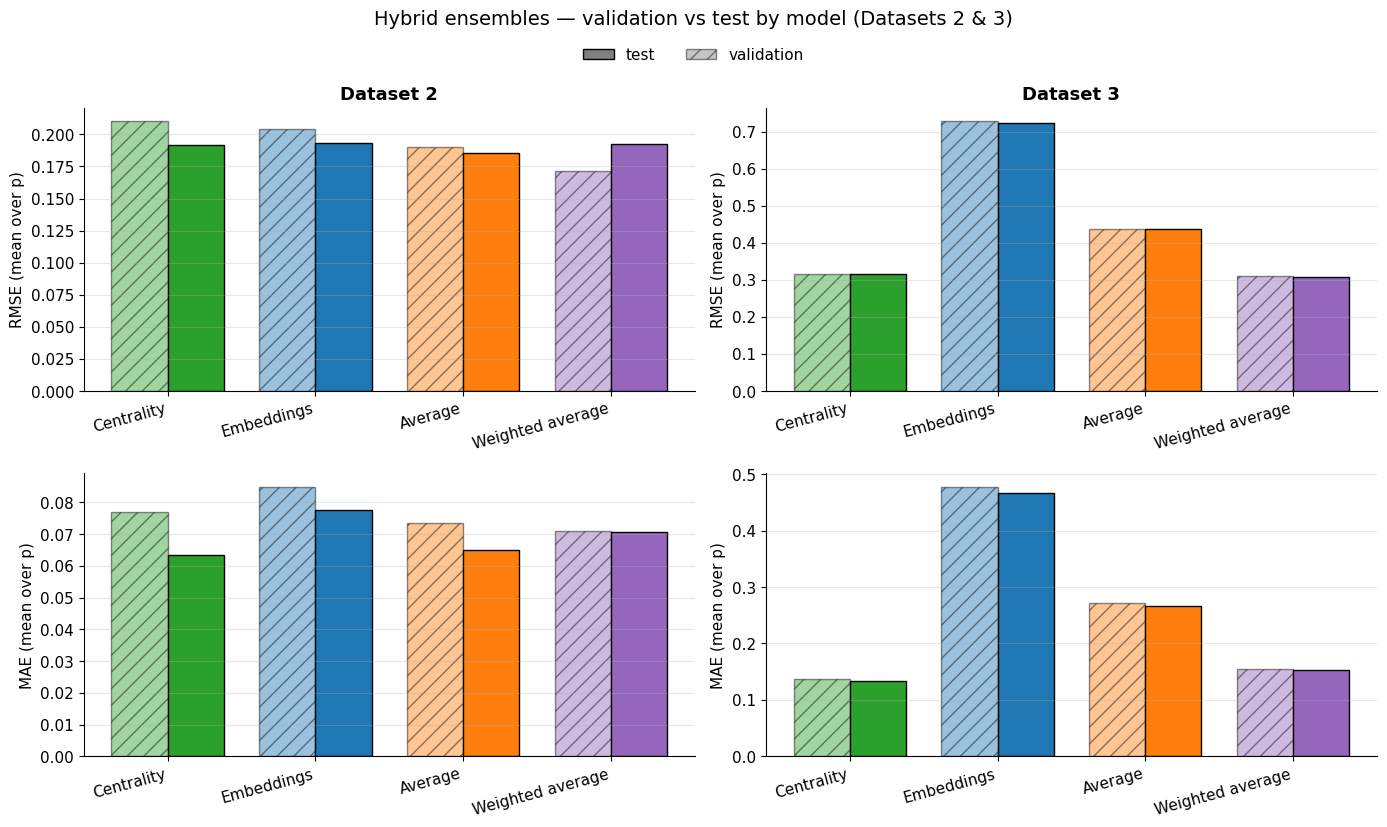

In [9]:
from pathlib import Path
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib.patches import Patch


def _find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for pth in [start, *start.parents]:
        if (pth / 'src').exists() and (pth / 'requirements.txt').exists():
            return pth
    raise FileNotFoundError('Project root not found.')


PRED_ROOT = _find_root() / 'src' / 'data' / 'predictions'
TC = 'log_systemic_risk_label'
P_LIST = ['p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']
hybrid_datasets = ['dataset_2', 'dataset_3']
hyb_rmse = lambda a, b: mean_squared_error(a, b) ** 0.5

# Same four models / colours as the notebook-06 ensemble plots.
HYB_COLORS = {'Centrality': '#2ca02c', 'Embeddings': '#1f77b4',
              'Average': '#ff7f0e', 'Weighted average': '#9467bd'}
hyb_methods = list(HYB_COLORS)

# Validation + test metrics per model, per p, from the saved threshold predictions.
vt_rows = []
for ds in hybrid_datasets:
    cen = pd.read_csv(PRED_ROOT / ds / 'centrality_threshold' / 'predictions.csv')
    emb = pd.read_csv(PRED_ROOT / ds / 'embedding_threshold' / 'predictions.csv')
    for p in P_LIST:
        c = cen[cen.p == p][['bank_id', 'split', TC, 'prediction']].rename(columns={'prediction': 'centrality_pred'})
        e = emb[emb.p == p][['bank_id', 'split', 'prediction']].rename(columns={'prediction': 'embedding_pred'})
        m = c.merge(e, on=['bank_id', 'split'], how='inner')
        val, test = m[m.split == 'validation'].copy(), m[m.split == 'test'].copy()
        if val.empty or test.empty:
            continue
        stk = LinearRegression().fit(val[['centrality_pred', 'embedding_pred']], val[TC])
        for split_name, d in [('validation', val), ('test', test)]:
            d = d.copy()
            d['average_pred'] = d[['centrality_pred', 'embedding_pred']].mean(axis=1)
            d['stacked_pred'] = stk.predict(d[['centrality_pred', 'embedding_pred']])
            y = d[TC]
            for method, col in [('Centrality', 'centrality_pred'), ('Embeddings', 'embedding_pred'),
                                ('Average', 'average_pred'), ('Weighted average', 'stacked_pred')]:
                vt_rows.append({'dataset': ds, 'method': method, 'split': split_name,
                                'rmse': hyb_rmse(y, d[col]), 'mae': mean_absolute_error(y, d[col])})

hybrid_valtest = pd.DataFrame(vt_rows)

# Small combined table (mean over p), datasets side by side.
hyb_table = (hybrid_valtest.groupby(['dataset', 'method', 'split'])[['rmse', 'mae']]
             .mean().round(3).reindex(hyb_methods, level='method'))
print('Hybrid validation vs test by model (mean over p)')
display(hyb_table)

# Combined figure: rows = RMSE / MAE, cols = Dataset 2 / Dataset 3.
x = np.arange(len(hyb_methods)); w = 0.38
fig, axes = plt.subplots(2, len(hybrid_datasets), figsize=(14, 8))
for r, (metric, mtitle) in enumerate([('rmse', 'RMSE'), ('mae', 'MAE')]):
    for cidx, ds in enumerate(hybrid_datasets):
        ax = axes[r, cidx]
        agg = hybrid_valtest[hybrid_valtest['dataset'] == ds].groupby(['method', 'split'])[metric].mean()
        for i, method in enumerate(hyb_methods):
            col = HYB_COLORS[method]
            ax.bar(x[i] - w / 2, agg.loc[(method, 'validation')], w, color=col,
                   edgecolor='black', alpha=0.45, hatch='//')
            ax.bar(x[i] + w / 2, agg.loc[(method, 'test')], w, color=col, edgecolor='black')
        if r == 0:
            ax.set_title(ds.replace('_', ' ').title())
        ax.set_ylabel(f'{mtitle} (mean over p)')
        ax.set_xticks(x); ax.set_xticklabels(hyb_methods, rotation=15, ha='right')
        ax.grid(True, axis='y', alpha=0.3)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
legend = [Patch(facecolor='gray', edgecolor='black', label='test'),
          Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='//', label='validation')]
fig.legend(handles=legend, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.suptitle('Hybrid ensembles — validation vs test by model (Datasets 2 & 3)', fontsize=14, y=1.03)
fig.tight_layout()
fig.savefig('hybrid_val_test_by_model_dataset2_3.png', dpi=150, bbox_inches='tight')
plt.show()